<font size = 8 color ='336EFF'>Density-Based Clustering</font>

### Import Relevant Libraries

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import csv
from scipy.spatial import distance
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

### DBSCAN class



In [9]:
class DBSCAN_2:
    """
    eps: Radius of neighborhood graph
    minPts: Number of neighbors required to label a given point as a core point.
    metric: Distance metric used to determine distance between points
    """
    def __init__(self, eps, minPts, metric=distance.euclidean):
        self.eps = eps
        self.minPts = minPts
        self.metric = metric

    def fit_predict(self, X):
        """
        X: An n-dimensional array of numeric vectors to be analyzed
        Returns: [n] cluster labels
        """
        clusters = [0] * X.shape[0]
        current = 0
        for i in range(0, X.shape[0]):
            if clusters[i] is not 0:
                continue
            neighbors = neighborsGen(X, i, self.eps, self.metric)

            if len(neighbors) < self.minPts:
                clusters[i] = -1
            else:
                current += 1
                expand(X, clusters, i, neighbors, current, self.eps, self.minPts, self.metric)

        return clusters

Generates neighborhood graph for a given point

In [10]:
def neighborsGen(X, point, eps, metric):
    neighbors = []
    for i in range(X.shape[0]):
        if metric(X[point], X[i]) < eps:
            neighbors.append(i)

    return neighbors

Expands cluster from a given point until neighborhood boundaries are reached

In [11]:
def expand(X, clusters, point, neighbors, current, eps, minPts, metric):
    clusters[point] = current
    i = 0
    while i < len(neighbors):
        nextPoint = neighbors[i]

        if clusters[nextPoint] == -1:
            clusters[nextPoint] = current
        elif clusters[nextPoint] == 0:
            clusters[nextPoint] = current
            nextNeighbors = neighborsGen(X, nextPoint, eps, metric)
            if len(nextNeighbors) >= minPts:
                neighbors = neighbors + nextNeighbors

        i += 1

Helper to illustrate accuracy of results

In [12]:
def checkEqual(l1, l2):
    return len(l1) == len(l2) and sorted(l1) == sorted(l2)

Import data

In [13]:
# your code
import os
import pandas as pd

# Remove any existing broken/empty file
if os.path.exists("Mall_Customers.csv"):
    os.remove("Mall_Customers.csv")

# Download from a verified public repository
!wget https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv -O Mall_Customers.csv

'wget' is not recognized as an internal or external command,
operable program or batch file.


Load file

In [ ]:
# load your dataset
# your code
df = pd.read_csv("Mall_Customers.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Mall_Customers.csv'

: 

Extract Null values

In [ ]:
# checking for NULL data in the dataset
# your code
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


Extract Columns Annual Income and Spending Score

In [ ]:
# extracting the above mentioned columns
# your code
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values
print(f"Dataset shape: {X.shape}")

Dataset shape: (200, 2)


In [ ]:
# create scanner
# your code
db_custom = DBSCAN_2(eps=5, minPts=5)
custom_labels = db_custom.fit_predict(X)
print("Custom DBSCAN clusters found:", set(custom_labels))

Custom DBSCAN clusters found: {1, 2, 3, 4, 5, -1}


In [ ]:
# Use Sklearn DBSCAN
# your code
db_sklearn = DBSCAN(eps=5, min_samples=5)
sklearn_labels = db_sklearn.fit_predict(X)
print("Sklearn DBSCAN clusters found:", set(sklearn_labels))

Sklearn DBSCAN clusters found: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(-1)}


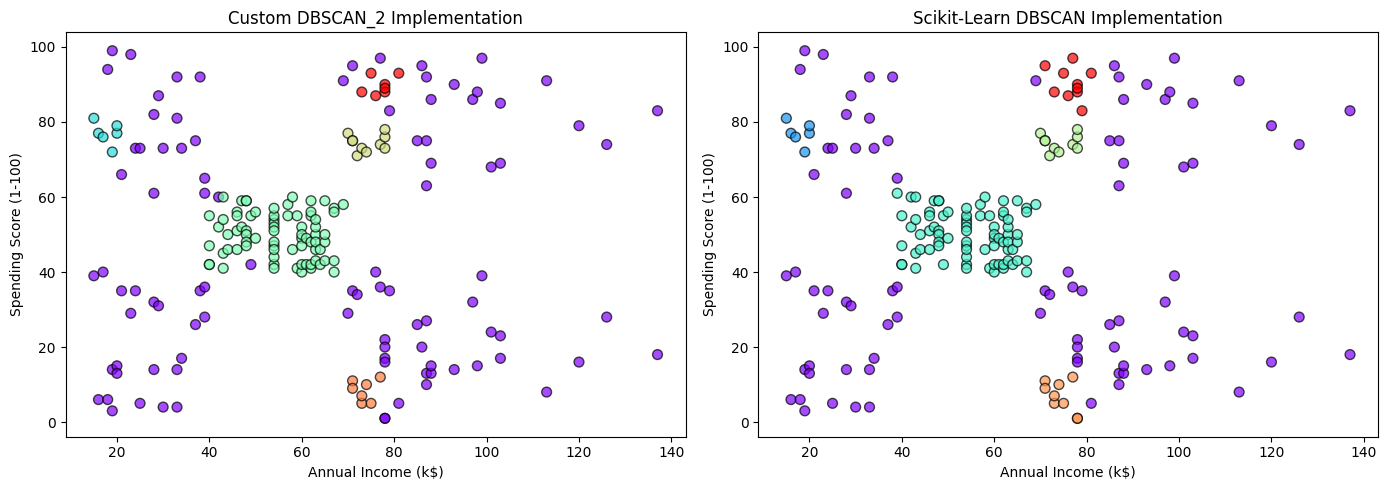

Are the list of assigned labels equal between custom and sklearn? False


In [ ]:
# Plot and compare results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Custom DBSCAN Plot
axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=custom_labels,
    cmap="rainbow",
    s=50,
    edgecolor="k",
    alpha=0.7,
)
axes[0].set_title("Custom DBSCAN_2 Implementation")
axes[0].set_xlabel("Annual Income (k$)")
axes[0].set_ylabel("Spending Score (1-100)")

# Sklearn DBSCAN Plot
axes[1].scatter(
    X[:, 0],
    X[:, 1],
    c=sklearn_labels,
    cmap="rainbow",
    s=50,
    edgecolor="k",
    alpha=0.7,
)
axes[1].set_title("Scikit-Learn DBSCAN Implementation")
axes[1].set_xlabel("Annual Income (k$)")
axes[1].set_ylabel("Spending Score (1-100)")

plt.tight_layout()
plt.show()

# Verification using checkEqual helper function
print(
    "Are the list of assigned labels equal between custom and sklearn?",
    checkEqual(custom_labels, sklearn_labels.tolist()),
)